# Hypothesis Testing

In [25]:
# correlation
from scipy import stats
import numpy as np

salary=np.array([-100,-200,300,400,500])
age=np.array([10,20,30,40,50])

In [26]:
# H0: No relation exist between 2 variable

# HA: Relation exist between 2 variable

In [27]:
coeff,pval=stats.pearsonr(salary,age)
print("coefficeint",coeff)
print("PVALUE is ",pval)

coefficeint 0.913811548620257
PVALUE is  0.029978621771262356


In [28]:
if pval<0.05:
    print("Alternate hypo---------Relation exist")
else:
    print("Null Hypo-----------No relation exist")

Alternate hypo---------Relation exist


In [29]:
coeff,pval=stats.spearmanr(salary,age)
print("coefficeint",coeff)
print("PVALUE is ",pval)

coefficeint 0.8999999999999998
PVALUE is  0.03738607346849874


In [30]:
if pval<0.05:
    print("Alternate hypo---------Relation exist")
else:
    print("Null Hypo-----------No relation exist")

Alternate hypo---------Relation exist


# one sample T test

For a particular organization, the average age of the employees was claimed 30 years.
The authorities collected a random sample of employees' age data to check the claim made by the organization.
Construct a hypothesis test to validate the hypothesis at a significance level of 0.05.

Ho = mean > 30

Ha = mean $\neq>$ 30

In [31]:
from scipy.stats import ttest_1samp
import pandas as pd
import numpy as np


ages = pd.read_csv("Ages.csv")
print(ages)


tset, pval = ttest_1samp(ages, 30,alternative="less")
print("p-values",pval)
if pval < 0.05:    # alpha value is 0.05 or 5%
    print(" HA: ANg age is not > 30")
else:
    print("H0: AVg age is > 30")

    ages
0     34
1     45
2     65
3     78
4     32
5     12
6     22
7     32
8     33
9     67
10    45
11    33
12    57
13    89
14    25
15    34
16    29
17    46
18    77
19    20
p-values [0.99493519]
H0: AVg age is > 30


In [32]:
ages_mean = np.mean(ages)
print(ages_mean)

43.75


### __Paired Sample T-Test: Example__

For a particular hospital, it is advertised that a particular chemotherapy session does not affect the patient's health
based on blood pressure.
It is to be checked if the blood pressure before the treatment is equivalent to the blood pressure after the treatment.
Perform a statistical test at the aplha 0.05 level to help validate the claim.

$H_0$ = Mean BP_ Before = mean BP_after

$H_1$ = Mean BP_ Before not = mean BP_after

In [33]:
import pandas as pd
from scipy import stats
df = pd.read_csv("blood_pressure.csv")
df.head()

,patient,sex,agegrp,bp_before,bp_after
0,1,Male,30-45,143,153
1,2,Male,30-45,163,170
2,3,Male,30-45,153,168
3,4,Male,30-45,153,142
4,5,Male,30-45,146,141


In [34]:
df[['bp_before','bp_after']].describe()

,bp_before,bp_after
count,120.000000,120.000000
mean,156.450000,151.358333
std,11.389845,14.177622
min,138.000000,125.000000
25%,147.000000,140.750000
50%,154.500000,149.500000
75%,164.000000,161.000000
max,185.000000,185.000000


In [35]:
df[['bp_before','bp_after']]
ttest,pval = stats.ttest_rel(df['bp_before'], df['bp_after'])
print(pval)
if pval<0.05:
    print("reject null hypothesis")
else:
    print("Failed to reject the null hypothesis")

0.0011297914644840823
reject null hypothesis


# Two Sample T Test

In [36]:
data=pd.read_csv("HR_newdata.csv")

In [37]:
data.head(2)

,Unnamed: 0,Individual,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Age1,MonthlyIncome1
0,0,Ind1,Yes,41,1,1102,1,1,2,1,...,0,8,0,1,6,4,0,5,43.1,8952.576429
1,1,Ind2,No,49,2,279,2,8,1,1,...,1,10,3,3,10,7,1,7,42.4,15078.533314


In [38]:
data['Gender'].value_counts()

Gender
1    882
2    588
Name: count, dtype: int64

In [39]:
# Whether this company showing any gender bias interms of providing salary ?


# Ho: Male salary = Female Salary (No bias)
# Ha: Male Salary != Female Salary


In [40]:
data[data['Gender']==1]['MonthlyIncome']

1       5130
2       2090
4       3468
5       3068
7       2693
        ... 
1465    2571
1466    9991
1467    6142
1468    5390
1469    4404
Name: MonthlyIncome, Length: 882, dtype: int64

In [41]:
grp1=data[data['Gender']==1]['MonthlyIncome1']
grp2=data[data['Gender']==2]['MonthlyIncome1']

In [42]:
len(grp1),len(grp2)

(882, 588)

In [43]:
np.mean(grp1),np.mean(grp2)

(np.float64(12062.942476392285), np.float64(12016.646623054548))

<Axes: xlabel='MonthlyIncome1', ylabel='Density'>

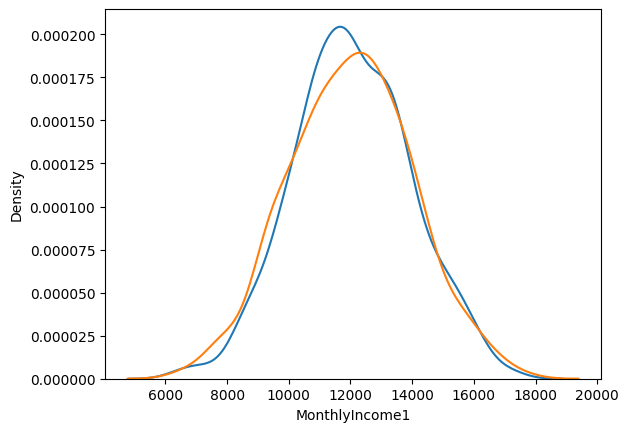

In [44]:
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")
sb.distplot(grp1,hist=False)
sb.distplot(grp2,hist=False)

In [45]:
#H0: Male salary = Female Salary
#H1: Male Salary != Female Salary
import numpy as np
import scipy.stats as stats
z,pval=stats.ttest_ind(grp1,grp2)
print(pval)
if pval>0.05:
    print("H0: Male salary = Female Salary")
else:
    print("HA : Male Salary != Female Salary")

0.6538869730579543
H0: Male salary = Female Salary


In [46]:
# Parametric test - Generally have some assumptions
# For ttest, the assumptions are
  #1. Each group data must be close to normal
  #2. Variance of group must close to each other

In [47]:
# Shapiro test for checking the Normality of the data
# H0 : Data is normally distributed
# Ha: Data is not normally Distributed

In [48]:
t,p=stats.shapiro(grp1)
if p>0.05:
    print(p,"Data can be normally distributed")
else:
    print(p,"Data is not normal")

0.34926065661570593 Data can be normally distributed


In [49]:
t,p=stats.shapiro(grp2)
if p>0.05:
    print(p,"Data can be normally distributed")
else:
    print(p,"Data is not normal")

0.7760067592469214 Data can be normally distributed


In [50]:
# Levene test is to check the varaince between two groups
# H0: Varaince between two group is same
# Ha: Varaince between the group is not same

t,p=stats.levene(grp1,grp2)
if p>0.05:
    print(p,"Variance can be same")
else:
    print(p,"Variance is not same")

0.19260073262980015 Variance can be same


In [51]:
# Mannwhitenyu Test - Non parametric test for two sample ttest
# H0: Median of group 1 = Median of group 2
# Ha: Median of two groups are not equal

zstats,pvaluem=stats.mannwhitneyu(grp1,grp2,alternative='two-sided')
if pvaluem>0.05:
    print("H0: median of Male salary = Female Salary")
else:
    print("HA: Median of Male Salary != Female Salary")

H0: median of Male salary = Female Salary


In [52]:
# Same perform for monthincome1

# Proportion_Test

One proportion Test

Two proportion Test

Chisqure Test

# One proportion Test

#Health officials of India is expecting cancer is affecting more men than women, 

#they are expecting 65% of affected case in India are Men. To verify this hypothesis, random

#samples (n=1500) across India were collected,the samples are as follows: Men:900, Women:600

In [53]:

# H0: Proportion of men affected = 65
# HA: Not equal to 65

In [56]:

from statsmodels.stats.proportion import proportions_ztest

In [57]:
zstat,pval=proportions_ztest(900,1500,.56)
zstat, pval

(np.float64(3.1622776601683733), np.float64(0.0015654022580025798))

In [ ]:
if pval>=0.05:
    print("HO: Proportion of men affected = 56")
else:
    print("HA: Proportion of men affected not equal to 56")

In [ ]:
#POST HOC(proof) for men
xbar = 900/1500
xbar

In [ ]:
sd=np.sqrt((900*(1-0.6)**2 + 600*(0-0.6)**2)/1500)

In [ ]:
import numpy as np
se=sd/np.sqrt(1500)
se

In [ ]:
#95 percent CF
#xbar +/- 1.96*se
[0.6-1.96*se,0.6+1.96*se]

# Two proportion Test

#Government are analyzing the impact of cancer in Rural and Urban Area, 
#The collected data showing the charactersistics below, Check the significance of Rural and Urban Area affecting the disease



In [ ]:
import pandas as pd
df=pd.DataFrame({'Rural':[867,490],'Urban':[500,550]})
df.index=['Negative','Positive']
df

In [ ]:
#H0 Cancer spread in urban = Cancer spread in rural
#Ha: Cancer spread in urban != Cancer spread in rural

In [ ]:
# Two sample proportion test
statss,pval=proportions_ztest([490,550],[490+867,500+550])
statss,pval

In [ ]:
if pval>=0.05:
    print("H0: Cancer spread in urban = Cancer spread in rural")
else:
    print("HA: Cancer spread in urban != Cancer spread in rural")

In [ ]:
#rural
490/1357

In [ ]:
550/1050

# Chi Square Test

In [ ]:
#The cancer data were collected from europe and india for the different age group categories
#Check the pattern is similar between two countries


In [ ]:
df=pd.DataFrame({'India':[1100,500,400],'europe':[800,450,300]})
df.index=['Seniors','Y&M','Childrens']
df

In [ ]:
#exp

In [ ]:
# H0: Spread of desease for differnt age category is same in India and Europe
#HA: not same

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
chi_stat,pval,df,exp=chi2_contingency(df)

In [ ]:
if pval>=0.05:
    print("H0: Spread of desease for differnt age category is same in India and Europe")
else:
    print("HA: Spread of desease for differnt age category is not same in India and Europe")

In [ ]:
exp

In [ ]:
import pandas as pd
import seaborn as sns
dataset=sns.load_dataset("tips")
dataset

In [ ]:
dataset["day"].value_counts()

In [ ]:
data=pd.crosstab(dataset["smoker"],dataset["sex"])
data

In [ ]:
data.values

In [ ]:
#help(stats.chi2_contingency)

In [ ]:
chi,pvalu,dof,exp=stats.chi2_contingency(data.values)
print("Chisquare",chi)
print("pvalue",pvalu)
print("expected",exp)

In [ ]:
if pvalu<0.05:
    print("Alternate hypo---------Relation exist")
else:
    print("Null Hypo-----------No relation exist")

# ANOVA Test

![ANOVA.png](https://s3.us-east-1.amazonaws.com/static2.simplilearn.com/lms/testpaper_images/ADSP/Advanced_Statistics/ANOVA.png)

In [ ]:
import pandas as pd
data=pd.read_excel("delivery.xlsx")

In [ ]:
#data.to_excel("delivery.xlsx")

In [ ]:
data.head(10)

In [ ]:
data["Region"].unique()

In [ ]:
gA=data[data['Region']=='A']['Minutes']
gB=data[data['Region']=='B']['Minutes']
gC=data[data['Region']=='C']['Minutes']

In [ ]:
gA

In [ ]:
# H0: The time taken to deliver the parcels in three regions are Same.
# HA: The time taken to deliver the parcels in three regions are differnt.

In [ ]:
# Anova is a parametric method - Check Assumptions
# Normality and levene

In [ ]:
stats.shapiro(data['Minutes'])
#H0:Data is normaly distributed
#pval is > 0.05, hence data can be consider as normal

In [ ]:
stats.levene(gA,gB,gC)
#H0: group variance are same

In [ ]:
sta,pval=stats.f_oneway(gA,gB,gC)

In [ ]:
if pval>=0.05:
    print("H0: The Avg time taken to deliver the parcels in three regions are Same")
else:
    print("HA:The Avg time taken to deliver the parcels in three regions are differnt")

In [ ]:
import seaborn as sns
sns.boxplot(x=data["Region"],y=data["Minutes"])

In [ ]:
# pval <0.05, Reject H0:
# The time taken to deliver the parcels in three regions are differnt.

In [ ]:
# ANalyse based on Truck age
data.head(5)

In [ ]:
data["TruckAge"].unique()

In [ ]:
data['TruckAge'].quantile([0.25,0.5,0.75])

In [ ]:
# 1 to 4 --- 'Brand New'
# 5 to 7 --- Medium
# >8-------->old

In [ ]:
data['TruckAge'].unique()

In [ ]:
# data binning
data['TruckAge_level']=pd.cut(data['TruckAge'],bins=[0,4,7,15],
                               labels=['New','Medium','Old'])

data.head(10)

In [ ]:
data['TruckAge_level'].unique()

In [ ]:
gA1=data[data['TruckAge_level']=='Old']['Minutes']
gB1=data[data['TruckAge_level']=='New']['Minutes']
gC1=data[data['TruckAge_level']=='Medium']['Minutes']

In [ ]:
stats.levene(gA1,gB1,gC1)


In [ ]:
sta,pval=stats.f_oneway(gA1,gB1,gC1)

In [ ]:
if pval>=0.05:
    print("H0: The time taken to deliver the parcels in vehicle  are same")
else:
    print("HA: The time taken to deliver the parcels in vehicle  are differnt")

In [ ]:
import seaborn as sns
sns.boxplot(x=data["TruckAge_level"],y=data["Minutes"])

In [ ]:
# # Hypothesis testing

# 1 sample t test----------->1 numerical features(eg: Avg sal>10000, avg sal =10000, avg sal<10000)
# 2 sample t test------------> 1 numerical, 1 categorial( should have only 2 levels) eg:Avg sal of male = Avg sal of female)
# Anova------>. 1 numerical vs 1 categorical(categorical may have more than 2 levels) eg.Avg sal in google,amazon,microsoft is same
# 1 proportion test--------> 1 categorical data
# 2 proportion test----------> relation between 2 categorical data(should have only 2 levels)
# chi square test---------->relation between 2 categorical data(categorical may have more than 2 levels)


# Shapiro-----------> to check the normality of the data
# levene-----------> to check the variance in the data